In [1]:
# Importing required libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
%matplotlib inline
import seaborn as sns
import scipy.stats as si
import statsmodels.api as sm
from statsmodels.tsa.ar_model import AutoReg
from scipy import stats as st
from scipy.optimize import least_squares
from tabulate import tabulate
import warnings
warnings.filterwarnings("ignore")
from scipy.stats.mstats import gmean
import statsmodels.formula.api as smf
import itertools
from itertools import product

c:\Users\YeonChan Kang\anaconda3\envs\fdb\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
import statsmodels.tsa.api as tsa
from scipy.stats import zscore

In [3]:
import wrds
conn = wrds.Connection()

WRDS recommends setting up a .pgpass file.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


# Data

In [4]:
# Factor Theme
usa_th_ew = pd.read_csv("C:/Users/YeonChan Kang/Desktop/Local_repo/Factor-Momentum-Reversal-and-Turning-Point/data/themes/[usa]_[all_themes]_[monthly]_[ew].csv")
usa_th_vw = pd.read_csv("C:/Users/YeonChan Kang/Desktop/Local_repo/Factor-Momentum-Reversal-and-Turning-Point/data/themes/[usa]_[all_themes]_[monthly]_[vw].csv")
usa_th_cvw = pd.read_csv("C:/Users/YeonChan Kang/Desktop/Local_repo/Factor-Momentum-Reversal-and-Turning-Point/data/themes/[usa]_[all_themes]_[monthly]_[vw_cap].csv")

In [5]:
# Factor
usa_fac_ew = pd.read_csv("C:/Users/YeonChan Kang/Desktop/Local_repo/Factor-Momentum-Reversal-and-Turning-Point/data/factors/[usa]_[all_factors]_[monthly]_[ew].csv")
usa_fac_vw = pd.read_csv("C:/Users/YeonChan Kang/Desktop/Local_repo/Factor-Momentum-Reversal-and-Turning-Point/data/factors/[usa]_[all_factors]_[monthly]_[vw].csv")
usa_fac_cvw = pd.read_csv("C:/Users/YeonChan Kang/Desktop/Local_repo/Factor-Momentum-Reversal-and-Turning-Point/data/factors/[usa]_[all_factors]_[monthly]_[vw_cap].csv")

In [6]:
# Manipulating the format of the data
usa_fac_ew.drop(columns = ['freq', 'weighting', 'location','n_stocks', 'n_stocks_min', 'direction'], inplace = True)
usa_fac_ew = usa_fac_ew.pivot_table(index='date', columns='name', values='ret')

usa_fac_vw.drop(columns = ['freq', 'weighting', 'location','n_stocks', 'n_stocks_min', 'direction'], inplace = True)
usa_fac_vw = usa_fac_vw.pivot_table(index='date', columns='name', values='ret')

usa_fac_cvw.drop(columns = ['freq', 'weighting', 'location','n_stocks', 'n_stocks_min', 'direction'], inplace = True)
usa_fac_cvw = usa_fac_cvw.pivot_table(index='date', columns='name', values='ret')

In [7]:
usa_fac_ew.index = pd.to_datetime(usa_fac_ew.index)
usa_fac_ew.index = usa_fac_ew.index.to_period('M')

usa_fac_cvw.index = pd.to_datetime(usa_fac_cvw.index)
usa_fac_cvw.index = usa_fac_cvw.index.to_period('M')

usa_fac_vw.index = pd.to_datetime(usa_fac_vw.index)
usa_fac_vw.index = usa_fac_vw.index.to_period('M')

In [8]:
ff_data = conn.raw_sql("""
                       SELECT *
                       FROM ff.factors_monthly
                       WHERE date between '01/01/1926' and '12/31/2023'
                       """)

In [9]:
ff_data.drop(columns=['date'], inplace=True)
ff_data.index.name = 'date'
ff_data.set_index('dateff', inplace=True)
ff_data.index = pd.to_datetime(ff_data.index)
ff_data.index = ff_data.index.to_period('M')

In [10]:
usa_fac_ewm = pd.merge(ff_data[['mktrf', 'smb', 'hml', 'umd']], usa_fac_ew, left_index=True, right_index=True, how='outer')

usa_fac_vwm = pd.merge(ff_data[['mktrf', 'smb', 'hml', 'umd']], usa_fac_vw, left_index=True, right_index=True, how='outer')

usa_fac_cvwm = pd.merge(ff_data[['mktrf', 'smb', 'hml', 'umd']], usa_fac_cvw, left_index=True, right_index=True, how='outer')

# Factor momentum everywhere

## Exhibit 1

In [13]:
## Cumulative Return
def calculate_cumulative_sum(df):
    # Calculate cumulative sum for each factor
    cumulative_sum = df.cumsum()
    return cumulative_sum

def plot_and_save_cumulative_returns(df, save_plots=False, output_dir='cumulative_returns', img_shows=True):
    cumulative_returns = calculate_cumulative_sum(df)
    
    # Create output directory if it does not exist
    if save_plots and not os.path.exists(output_dir):
        os.makedirs(output_dir)
    df.index = df.index.to_timestamp()
    # Plot and save cumulative returns for each factor
    for column in df.columns:
        plt.figure(figsize=(10, 5))
        plt.plot(df.index, cumulative_returns[column], label=f'Cumulative {column}')
        plt.title(f'Cumulative Returns for {column}')
        plt.xlabel('Date')
        plt.ylabel('Cumulative Return')
        plt.legend()
        
        # Adding horizontal lines only on y-axis
        plt.grid(True, axis='y', linestyle='--', linewidth=0.5)
        
        # Setting x-axis ticks to be every 10 years
        plt.gca().xaxis.set_major_locator(plt.MaxNLocator(nbins=int(len(df.index) / (12*10))))
        
        # Set x-tick labels to be smaller
        plt.xticks(fontsize=8, rotation=45)
        
        if save_plots:
            plt.savefig(os.path.join(output_dir, f'cumulative_{column}_returns.png'))
        
        if img_shows:
            plt.show()
        else:
            plt.close()

In [ ]:
plot_and_save_cumulative_returns(usa_fac_cvwm, img_shows=True)

In [15]:
cumulative_returns = calculate_cumulative_sum(usa_fac_cvwm)

### Alpha

In [29]:
def calculate_statistics(df, factor_name, rf_col='rf', annualization_method='compound'):
    
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=[factor_name])
    
    if rf_col is not None:
        y = df[factor_name] - df[rf_col]
    else:
        y = df[factor_name]
    
    X = df['mktrf']
    X = sm.add_constant(X)
    
    # Calculate average returns (Annualized)
    avg_return_ann = df[factor_name].mean() * 12
    avg_return_std = df[factor_name].std() * np.sqrt(12)
    avg_return_ci = st.t.interval(0.95, len(df[factor_name])-1, loc=avg_return_ann, scale=st.sem(df[factor_name]*12))
    
    # Calculate volatility (Annualized)
    volatility_ann = df[factor_name].std() * np.sqrt(12)
    volatility_ci = (volatility_ann - avg_return_std, volatility_ann + avg_return_std)

    # Calculate Sharpe Ratio
    sharpe_ratio = avg_return_ann / volatility_ann
    sharpe_ratio_ci = st.t.interval(0.95, len(df[factor_name])-1, loc=sharpe_ratio, scale=st.sem(df[factor_name] / volatility_ann))
    
    model = sm.OLS(y, X).fit()
    monthly_alpha = model.params['const']
    beta = model.params['mktrf']
    alpha_ci = model.conf_int().loc['const'].values * 12
    beta_ci = model.conf_int().loc['mktrf'].values

    # Annualize alpha
    if annualization_method == 'compound':
        annual_alpha = ((1 + monthly_alpha) ** 12) - 1
    elif annualization_method == 'simple':
        annual_alpha = monthly_alpha * 12
    else:
        ValueError("annualization_method must be 'compound' or 'simple'")

    # Compile results
    results = {
        'Average Returns (Ann. %)': round(avg_return_ann * 100, 2),
        'Volatility (Ann. %)': round(volatility_ann * 100, 2),
        'Sharpe Ratio': round(sharpe_ratio, 2),
         # 'Info. Ratio': info_ratio,
        'Alpha (Ann. %)': round(annual_alpha * 100, 2),
        'Beta': round(beta, 2)
    }
    
    ci_results = {
        'Average Returns (Ann. %)': (round(avg_return_ci[0] * 100, 2), round(avg_return_ci[1] * 100, 2)),
        'Volatility (Ann. %)': (round(volatility_ci[0] * 100, 2), round(volatility_ci[1] * 100, 2)),
        'Sharpe Ratio': (round(sharpe_ratio_ci[0], 2), round(sharpe_ratio_ci[1], 2)),
        'Alpha (Ann. %)': (round(alpha_ci[0] * 100, 2), round(alpha_ci[1] * 100, 2)),
        'Beta': (round(beta_ci[0], 2), round(beta_ci[1], 2))
    }
    
    formatted_results = {key: f"{value:.2f}" for key, value in results.items()}
    formatted_ci_results = {key: (f"{value[0]:.2f}", f"{value[1]:.2f}") for key, value in ci_results.items()}

    return formatted_results, formatted_ci_results

In [30]:
def calculate_statistics_for_periods(data, factor_name, risk_free_rate_col=None, annualization_method='compound'):
    if isinstance(data.index, pd.PeriodIndex):
        data.index = data.index.to_timestamp()  # Convert PeriodIndex to DatetimeIndex if necessary

    end_date = data.index.max()
    periods = {
        '1 Year': end_date - pd.DateOffset(years=1),
        '3 Years': end_date - pd.DateOffset(years=3),
        '5 Years': end_date - pd.DateOffset(years=5),
        '10 Years': end_date - pd.DateOffset(years=10),
        'Full Sample': data.index.min()
    }

    results = {}
    ci_results = {}
    for period_name, start_date in periods.items():
        filtered_data = data.loc[start_date:end_date]
        period_results, period_ci = calculate_statistics(filtered_data, factor_name, risk_free_rate_col, annualization_method=annualization_method)
        results[period_name] = period_results
        ci_results[period_name] = period_ci
    
    # Convert results to a DataFrame
    results_df = pd.DataFrame(results)  
    ci_results_df = pd.DataFrame(ci_results)  

    return results_df, ci_results_df


In [31]:
def calculate_all_factors(data, factors, risk_free_rate_col=None, annualization_method='simple'):
    all_results = {}
    all_ci_results = {}
    for factor in factors:
        results_df, ci_results_df = calculate_statistics_for_periods(data, factor, risk_free_rate_col, annualization_method=annualization_method)
        all_results[factor] = results_df
        all_ci_results[factor] = ci_results_df
    return all_results, all_ci_results

In [ ]:
factor_ss, factor_ci_ss = calculate_all_factors(usa_fac_cvwm, usa_fac_cvwm.columns, risk_free_rate_col=None, annualization_method='simple')

In [42]:
def calculate_statistics(df, factor_name, rf_col='rf', annualization_method='compound'):
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=[factor_name, 'mktrf'])
    
    if rf_col is not None and rf_col in df.columns:
        y = df[factor_name] - df[rf_col]
    else:
        y = df[factor_name]
    
    X = df['mktrf']
    X = sm.add_constant(X)

    # Calculate average returns (Annualized)
    avg_return_ann = df[factor_name].mean() * 12
    avg_return_std = df[factor_name].std() * np.sqrt(12)
    avg_return_ci = st.t.interval(0.95, len(df[factor_name])-1, loc=avg_return_ann, scale=st.sem(df[factor_name]) * 12)
    
    # Calculate volatility (Annualized)
    volatility_ann = df[factor_name].std() * np.sqrt(12)
    volatility_ci = (volatility_ann - avg_return_std, volatility_ann + avg_return_std)

    # Calculate Sharpe Ratio
    sharpe_ratio = avg_return_ann / volatility_ann
    sharpe_ratio_std_error = (1 / np.sqrt(len(df))) * (1 + (sharpe_ratio ** 2) / 2)
    sharpe_ratio_ci_lower = sharpe_ratio - 1.96 * sharpe_ratio_std_error
    sharpe_ratio_ci_upper = sharpe_ratio + 1.96 * sharpe_ratio_std_error
    sharpe_ratio_ci = (sharpe_ratio_ci_lower, sharpe_ratio_ci_upper)
        
    model = sm.OLS(y, X).fit()
    monthly_alpha = model.params['const']
    beta = model.params['mktrf']
    alpha_ci = model.conf_int().loc['const'].values * 12
    beta_ci = model.conf_int().loc['mktrf'].values

    # Annualize alpha
    if annualization_method == 'compound':
        annual_alpha = ((1 + monthly_alpha) ** 12) - 1
    elif annualization_method == 'simple':
        annual_alpha = monthly_alpha * 12
    else:
        raise ValueError("annualization_method must be 'compound' or 'simple'")

    # Compile results
    results = {
        'Average Returns (Ann. %)': round(avg_return_ann * 100, 2),
        'Volatility (Ann. %)': round(volatility_ann * 100, 2),
        'Sharpe Ratio': round(sharpe_ratio, 2),
        'Alpha (Ann. %)': round(annual_alpha * 100, 2),
        'Beta': round(beta, 2)
    }
    
    ci_results = {
        'Average Returns (Ann. %)': (round(avg_return_ci[0] * 100, 2), round(avg_return_ci[1] * 100, 2)),
        'Volatility (Ann. %)': (round(volatility_ci[0] * 100, 2), round(volatility_ci[1] * 100, 2)),
        'Sharpe Ratio': (round(sharpe_ratio_ci[0], 2), round(sharpe_ratio_ci[1], 2)),
        'Alpha (Ann. %)': (round(alpha_ci[0] * 100, 2), round(alpha_ci[1] * 100, 2)),
        'Beta': (round(beta_ci[0], 2), round(beta_ci[1], 2))
    }

    return results, ci_results

def calculate_statistics_for_periods(data, factor_name, rf_col=None, annualization_method='compound'):
    if isinstance(data.index, pd.PeriodIndex):
        data.index = data.index.to_timestamp()  # Convert PeriodIndex to DatetimeIndex if necessary

    end_date = data.index.max()
    periods = {
        '1 Year': end_date - pd.DateOffset(years=1),
        '3 Years': end_date - pd.DateOffset(years=3),
        '5 Years': end_date - pd.DateOffset(years=5),
        '10 Years': end_date - pd.DateOffset(years=10),
        'Full Sample': data.index.min()
    }

    results = {}
    ci_results = {}
    for period_name, start_date in periods.items():
        filtered_data = data.loc[start_date:end_date]
        if len(filtered_data) < 12:  # 데이터가 12개월 미만이면 통계를 계산하지 않음
            continue
        period_results, period_ci = calculate_statistics(filtered_data, factor_name, rf_col, annualization_method=annualization_method)
        results[period_name] = period_results
        ci_results[period_name] = period_ci
    
    return pd.DataFrame(results), pd.DataFrame(ci_results)

def calculate_all_factors(data, factors, rf_col=None, annualization_method='simple'):
    all_results = {}
    all_ci_results = {}
    for factor in factors:
        results_df, ci_results_df = calculate_statistics_for_periods(data, factor, rf_col, annualization_method=annualization_method)
        all_results[factor] = results_df
        all_ci_results[factor] = ci_results_df
    return all_results, all_ci_results

In [43]:
factor_ss, factor_ci_ss = calculate_all_factors(usa_fac_cvwm, usa_fac_cvwm.columns, rf_col=None, annualization_method='simple')

In [44]:
def plot_statistics(all_results, all_ci_results, period, metric, output_path, show_plot=False):
    metric_map = {
        'average_return': 'Average Returns (Ann. %)',
        'volatility': 'Volatility (Ann. %)',
        'sharpe_ratio': 'Sharpe Ratio',
        'alpha': 'Alpha (Ann. %)',
        'beta': 'Beta'
    }
    
    if period not in ['1 Year', '3 Years', '5 Years', '10 Years', 'Full Sample']:
        raise ValueError("Invalid period. Choose from '1 Year', '3 Years', '5 Years', '10 Years', 'Full Sample'.")
    if metric not in metric_map:
        raise ValueError("Invalid metric. Choose from 'average_return', 'volatility', 'sharpe_ratio', 'alpha', 'beta'.")

    metric_label = metric_map[metric]

    factors = list(all_results.keys())
    values = [float(all_results[factor][period][metric_label]) for factor in factors]
    ci_lower = [float(all_results[factor][period][metric_label]) - float(all_ci_results[factor][period][metric_label][0]) for factor in factors]
    ci_upper = [float(all_ci_results[factor][period][metric_label][1]) - float(all_results[factor][period][metric_label]) for factor in factors]

    # Create a DataFrame to facilitate sorting
    df = pd.DataFrame({
        'factor': factors,
        'value': values,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper
    })

    # Sort the DataFrame by 'value' in ascending order
    df = df.sort_values(by='value')

    # Extract sorted values
    sorted_factors = df['factor'].tolist()
    sorted_values = df['value'].tolist()
    sorted_ci_lower = df['ci_lower'].tolist()
    sorted_ci_upper = df['ci_upper'].tolist()

    plt.figure(figsize=(16, 10))  # Increased figure size
    plt.bar(sorted_factors, sorted_values, yerr=[sorted_ci_lower, sorted_ci_upper], capsize=5, color='gray', alpha=0.7)
    plt.xticks(rotation=90, fontsize=10)  # Increased font size for factor names
    plt.xlabel('Factors', fontsize=12)
    plt.ylabel(metric_label, fontsize=12)
    plt.title(f'{metric_label} for {period}', fontsize=14)
    plt.grid(True)
    plt.tight_layout()
    
    if output_path is not None:
        plt.savefig(output_path)
    
    # Show the plot if requested
    if show_plot:
        plt.show()
    else:
        plt.close()

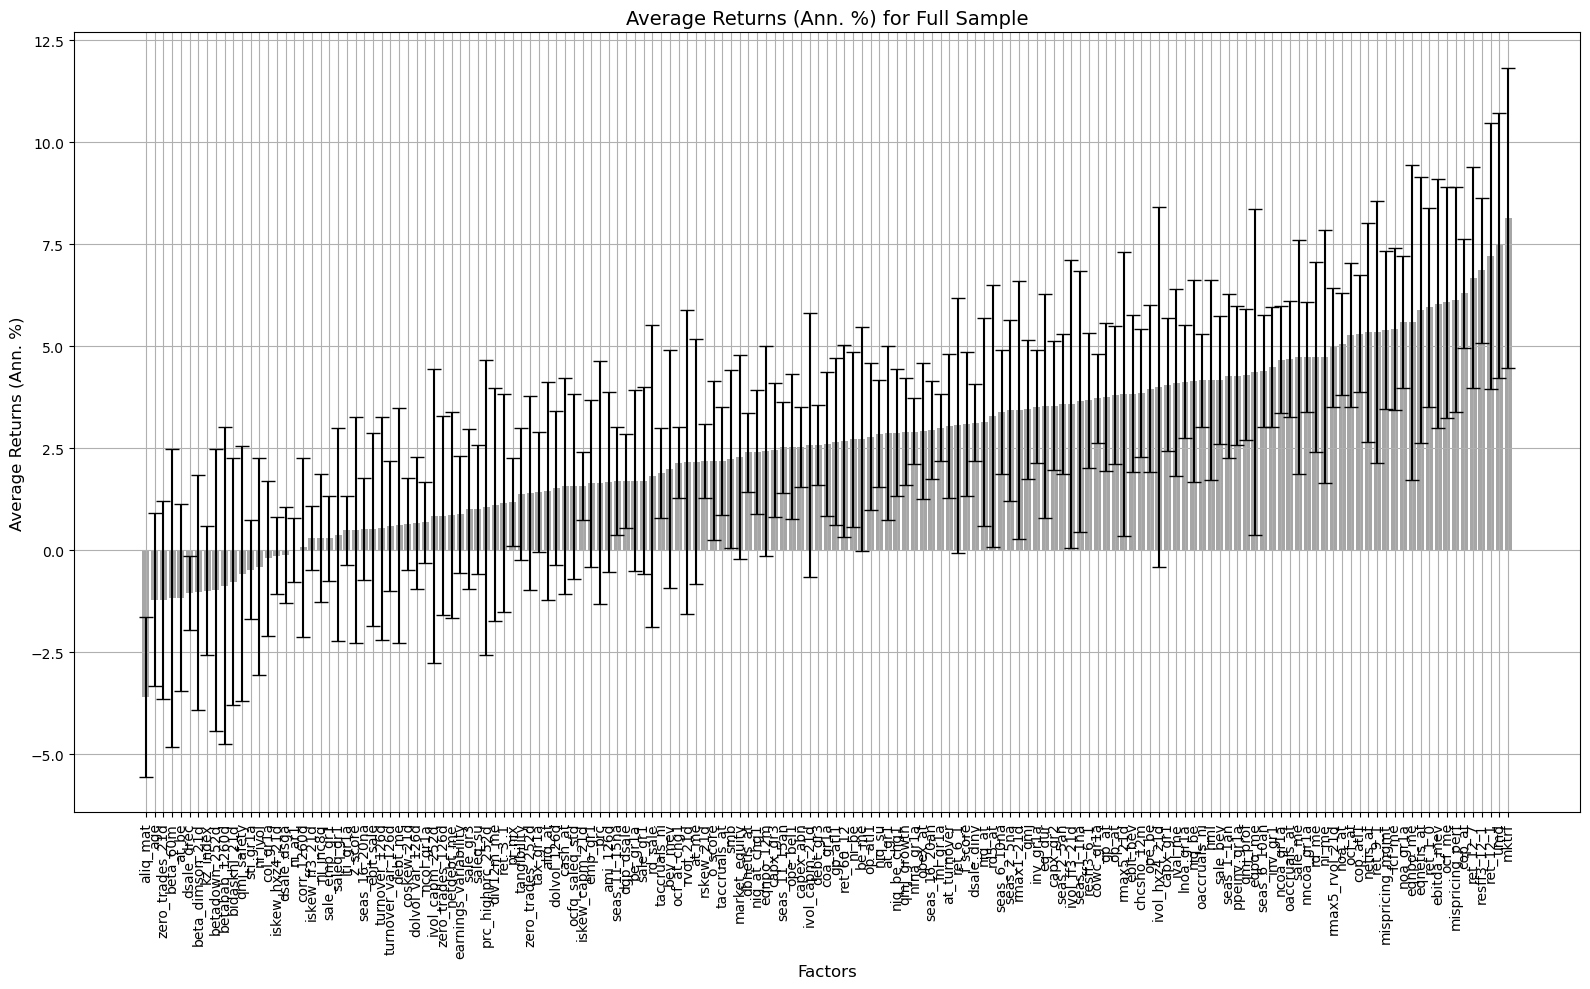

In [39]:
plot_statistics(factor_ss, factor_ci_ss, 'Full Sample', 'average_return', output_path=None, show_plot=True)

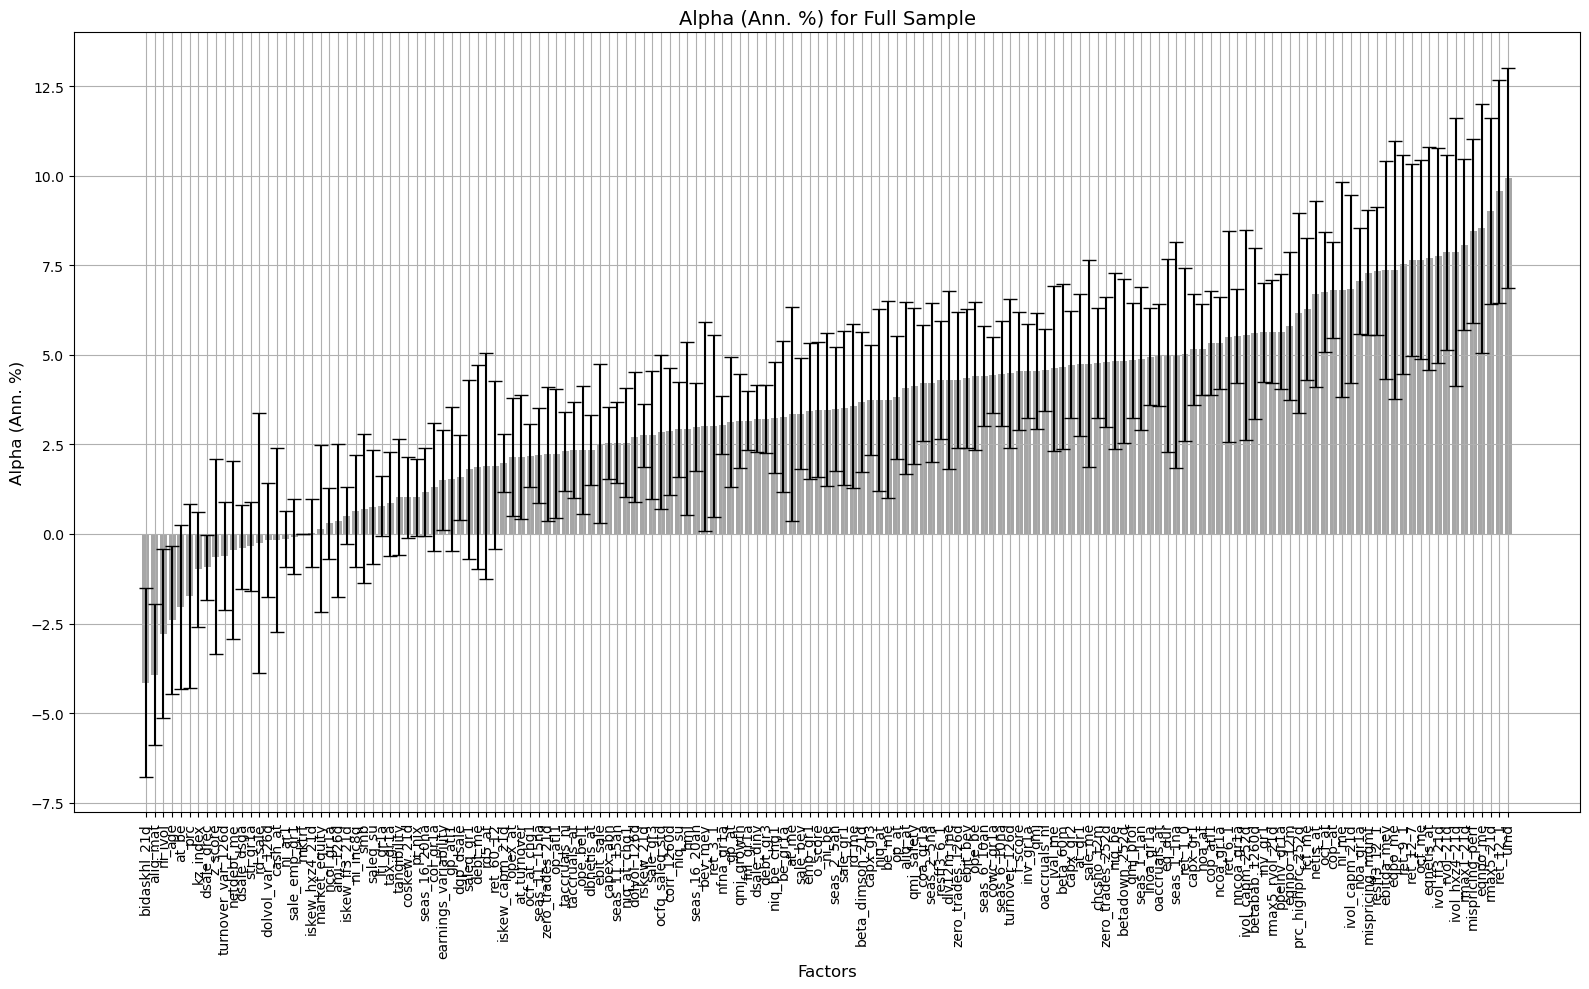

In [40]:
plot_statistics(factor_ss, factor_ci_ss, 'Full Sample', 'alpha', output_path=None, show_plot=True)

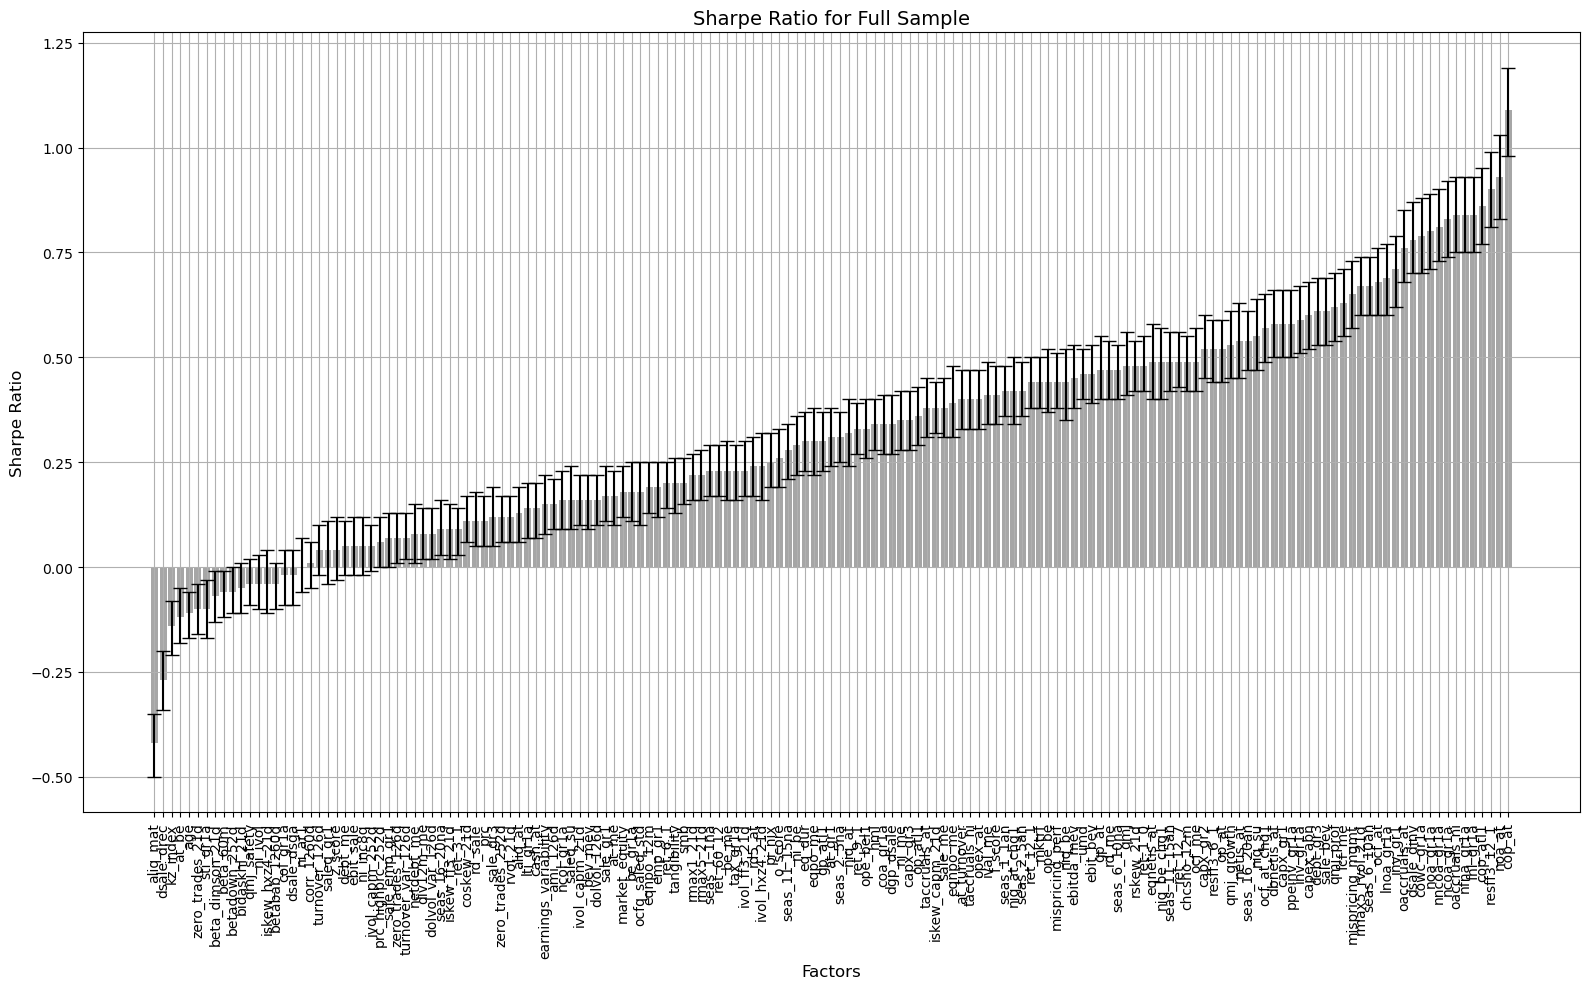

In [45]:
plot_statistics(factor_ss, factor_ci_ss, 'Full Sample', 'sharpe_ratio', output_path=None, show_plot=True)

In [207]:
def calculate_t_statistics(results, ci_results, stat, period, confidence_level=0.95):
    t_statistics = {}

    # 신뢰수준에 따른 z-value 계산
    z_value = st.norm.ppf((1 + confidence_level) / 2)

    for key in results:
        # 통계량 추정치
        estimate = results[key][period].loc[stat]
        
        # 신뢰구간
        ci_lower, ci_upper = ci_results[key][period].loc[stat]
        
        # 표준 오차 계산
        se = (ci_upper - ci_lower) / (2 * z_value)
        
        # t-statistic 계산
        t_stat = estimate / se
        t_statistics[key] = round(t_stat, 2)
    
    return t_statistics

In [218]:
def add_significance_stars(value, t_stat):
    """신뢰수준에 따라 유의성 별표 추가"""
    # 99% 신뢰수준
    if abs(t_stat) > 2.576:
        return f"{value}***"
    # 95% 신뢰수준
    elif abs(t_stat) > 1.96:
        return f"{value}**"
    # 90% 신뢰수준
    elif abs(t_stat) > 1.645:
        return f"{value}*"
    # 유의성이 없는 경우
    return f"{value}"

def extract_statistics_with_significance(factor_ss, factor_ci_ss, period, confidence_level=0.95):
    results = {}

    avg_return_t_stat = calculate_t_statistics(factor_ss, factor_ci_ss, 'Average Returns (Ann. %)', period)
    sharpe_ratio_t_stat = calculate_t_statistics(factor_ss, factor_ci_ss, 'Sharpe Ratio', period)
    alpha_t_stat = calculate_t_statistics(factor_ss, factor_ci_ss, 'Alpha (Ann. %)', period)

    for factor in factor_ss.keys():
        
        avg_return_with_significance = add_significance_stars(factor_ss[factor][period].loc['Average Returns (Ann. %)'], avg_return_t_stat[factor], confidence_level)
        sharpe_ratio_with_significance = add_significance_stars(factor_ss[factor][period].loc['Sharpe Ratio'], sharpe_ratio_t_stat[factor], confidence_level)
        alpha_with_significance = add_significance_stars(factor_ss[factor][period].loc['Alpha (Ann. %)'], alpha_t_stat[factor], confidence_level)

        
        results[factor] = {
            'Average Return': avg_return_with_significance,
            'Average Return t-stat': avg_return_t_stat[factor],
            'Sharpe Ratio': sharpe_ratio_with_significance,
            'Sharpe Ratio t-stat': sharpe_ratio_t_stat[factor],
            'Alpha': alpha_with_significance,
            'Alpha t-stat': alpha_t_stat[factor]
        }

    # Convert the results dictionary to a DataFrame
    result_df = pd.DataFrame(results).T
    
    return result_df

In [219]:
result1 = extract_statistics_with_significance(factor_ss, factor_ci_ss, 'Full Sample', confidence_level=0.90)
result1

,Average Return,Average Return t-stat,Sharpe Ratio,Sharpe Ratio t-stat,Alpha,Alpha t-stat
mktrf,8.14***,3.64,0.44***,12.06,0.0,NaN
smb,2.24*,1.69,0.2***,5.98,0.71,0.56
hml,4.17***,2.79,0.34***,9.32,2.93**,2.0
umd,7.48***,3.79,0.46***,12.61,9.93***,5.31
age,-1.21,-0.94,-0.11***,-3.29,-2.4*,-1.91
...,...,...,...,...,...,...
turnover_var_126d,0.59,0.61,0.07**,2.09,-0.61,-0.67
z_score,0.5,0.3,0.04,0.88,-0.63,-0.38
zero_trades_126d,0.85,0.57,0.07*,1.92,4.31***,3.74
zero_trades_21d,-1.21,-0.82,-0.1***,-2.74,2.23*,1.96


In [220]:
result2 = extract_statistics_with_significance(factor_ss, factor_ci_ss, 'Full Sample', confidence_level=0.95)
result2

,Average Return,Average Return t-stat,Sharpe Ratio,Sharpe Ratio t-stat,Alpha,Alpha t-stat
mktrf,8.14***,4.34,0.44***,14.37,0.0,NaN
smb,2.24**,2.01,0.2***,7.13,0.71,0.67
hml,4.17***,3.33,0.34***,11.11,2.93**,2.38
umd,7.48***,4.52,0.46***,15.03,9.93***,6.33
age,-1.21,-1.12,-0.11***,-3.92,-2.4**,-2.27
...,...,...,...,...,...,...
turnover_var_126d,0.59,0.73,0.07**,2.49,-0.61,-0.8
z_score,0.5,0.35,0.04,1.05,-0.63,-0.45
zero_trades_126d,0.85,0.68,0.07**,2.29,4.31***,4.46
zero_trades_21d,-1.21,-0.98,-0.1***,-3.27,2.23**,2.33


In [221]:
result3 = extract_statistics_with_significance(factor_ss, factor_ci_ss, 'Full Sample', confidence_level=0.99)
result3

,Average Return,Average Return t-stat,Sharpe Ratio,Sharpe Ratio t-stat,Alpha,Alpha t-stat
mktrf,8.14***,5.7,0.44***,18.89,0.0,NaN
smb,2.24***,2.64,0.2***,9.37,0.71,0.88
hml,4.17***,4.38,0.34***,14.6,2.93***,3.13
umd,7.48***,5.94,0.46***,19.75,9.93***,8.32
age,-1.21,-1.47,-0.11***,-5.15,-2.4***,-2.99
...,...,...,...,...,...,...
turnover_var_126d,0.59,0.96,0.07***,3.28,-0.61,-1.05
z_score,0.5,0.46,0.04,1.37,-0.63,-0.6
zero_trades_126d,0.85,0.9,0.07***,3.01,4.31***,5.86
zero_trades_21d,-1.21,-1.29,-0.1***,-4.29,2.23***,3.06


In [195]:
print(tabulate(result, headers='keys', tablefmt='pretty'))

+----------------------+----------------+-----------------------+--------------+---------------------+----------+--------------+
|                      | Average Return | Average Return t-stat | Sharpe Ratio | Sharpe Ratio t-stat |  Alpha   | Alpha t-stat |
+----------------------+----------------+-----------------------+--------------+---------------------+----------+--------------+
|        mktrf         |    8.14***     |         4.34          |   0.44***    |        14.37        |   0.0    |     nan      |
|         smb          |    2.24***     |         2.01          |    0.2***    |        7.13         |   0.71   |     0.67     |
|         hml          |    4.17***     |         3.33          |   0.34***    |        11.11        | 2.93***  |     2.38     |
|         umd          |    7.48***     |         4.52          |   0.46***    |        15.03        | 9.93***  |     6.33     |
|         age          |     -1.21      |         -1.12         |   -0.11***   |        -3.92    

In [180]:
def add_significance_stars(value, ci_lower, ci_upper, significance_level=0.01):
    """신뢰구간이 0을 포함하지 않으면 유의성 별표 추가"""
    # Significance level에 따른 별표 추가
    if significance_level == 0.01:
        if ci_lower > 0 or ci_upper < 0:
            return f"{value}***"
    elif significance_level == 0.05:
        if ci_lower > 0 or ci_upper < 0:
            return f"{value}**"
    elif significance_level == 0.10:
        if ci_lower > 0 or ci_upper < 0:
            return f"{value}*"
    return f"{value}"  # 유의성이 없는 경우

def extract_statistics_with_significance(factor_ss, factor_ci_ss, data_period, significance_level=0.01):
    results = {}

    for factor in factor_ss.keys():
        # Extract the relevant statistics for the specified data period
        avg_return = factor_ss[factor].loc['Average Returns (Ann. %)', data_period]
        sharpe_ratio = factor_ss[factor].loc['Sharpe Ratio', data_period]
        alpha = factor_ss[factor].loc['Alpha (Ann. %)', data_period]

        # Use existing confidence intervals instead of recalculating
        avg_return_ci_lower = factor_ci_ss[factor].loc['Average Returns (Ann. %)', data_period][0]
        avg_return_ci_upper = factor_ci_ss[factor].loc['Average Returns (Ann. %)', data_period][1]
        
        sharpe_ratio_ci_lower = factor_ci_ss[factor].loc['Sharpe Ratio', data_period][0]
        sharpe_ratio_ci_upper = factor_ci_ss[factor].loc['Sharpe Ratio', data_period][1]
        
        alpha_ci_lower = factor_ci_ss[factor].loc['Alpha (Ann. %)', data_period][0]
        alpha_ci_upper = factor_ci_ss[factor].loc['Alpha (Ann. %)', data_period][1]

        # Calculate t-statistics
        avg_return_t_stat = avg_return / ((avg_return_ci_upper - avg_return_ci_lower) / (2 * 1.96))
        sharpe_ratio_t_stat = sharpe_ratio / ((sharpe_ratio_ci_upper - sharpe_ratio_ci_lower) / (2 * 1.96))
        alpha_t_stat = alpha / ((alpha_ci_upper - alpha_ci_lower) / (2 * 1.96))

        # Add significance stars based on confidence intervals and specified significance level
        avg_return_with_significance = add_significance_stars(avg_return, avg_return_ci_lower, avg_return_ci_upper, significance_level)
        sharpe_ratio_with_significance = add_significance_stars(sharpe_ratio, sharpe_ratio_ci_lower, sharpe_ratio_ci_upper, significance_level)
        alpha_with_significance = add_significance_stars(alpha, alpha_ci_lower, alpha_ci_upper, significance_level)

        # Store the results in a dictionary
        results[factor] = {
            'Average Return': avg_return_with_significance,
            'Average Return t-stat': round(avg_return_t_stat, 2),
            'Sharpe Ratio': sharpe_ratio_with_significance,
            'Sharpe Ratio t-stat': round(sharpe_ratio_t_stat, 2),
            'Alpha': alpha_with_significance,
            'Alpha t-stat': round(alpha_t_stat, 2)
        }

    # Convert the results dictionary to a DataFrame
    result_df = pd.DataFrame(results).T
    
    return result_df

result = extract_statistics_with_significance(factor_ss, factor_ci_ss, 'Full Sample')

result

,Average Return,Average Return t-stat,Sharpe Ratio,Sharpe Ratio t-stat,Alpha,Alpha t-stat
mktrf,8.14***,4.34,0.44***,14.37,0.0,NaN
smb,2.24***,2.01,0.2***,7.13,0.71,0.67
hml,4.17***,3.33,0.34***,11.11,2.93***,2.38
umd,7.48***,4.52,0.46***,15.03,9.93***,6.33
age,-1.21,-1.12,-0.11***,-3.92,-2.4***,-2.27
...,...,...,...,...,...,...
turnover_var_126d,0.59,0.73,0.07***,2.49,-0.61,-0.8
z_score,0.5,0.35,0.04,1.05,-0.63,-0.45
zero_trades_126d,0.85,0.68,0.07***,2.29,4.31***,4.46
zero_trades_21d,-1.21,-0.98,-0.1***,-3.27,2.23***,2.33


In [186]:
def identify_significant_factors(result_df, threshold=1.96):
    """
    Identifies factors with significant Average Return and Alpha based on the given t-statistic thresholds.
    
    Parameters:
    - result_df: DataFrame containing t-statistics
    - threshold: t-statistic threshold for Average Return and Alpha significance (default: 1.96, corresponding to a 5% significance level)
    
    Returns:
    - significant_avg_return_factors: List of factors with significant Average Return
    - significant_alpha_factors: List of factors with significant Alpha
    - significant_both_factors: List of factors with both significant Average Return and Alpha
    """
    
    # Identify factors with significant Average Return
    significant_avg_return_factors = result_df[result_df['Average Return t-stat'].abs() >= threshold].index.tolist()
    
    # Identify factors with significant Alpha
    significant_alpha_factors = result_df[result_df['Alpha t-stat'].abs() >= threshold].index.tolist()
    
    # Identify factors with both significant Average Return and Alpha
    significant_both_factors = result_df[
        (result_df['Average Return t-stat'].abs() >= threshold) &
        (result_df['Alpha t-stat'].abs() >= threshold)
    ].index.tolist()
    
    return significant_avg_return_factors, significant_alpha_factors, significant_both_factors



In [187]:
significant_avg_return, significant_alpha, significant_both = identify_significant_factors(result)

In [188]:
len(significant_avg_return), len(significant_alpha), len(significant_both)

(95, 123, 89)

In [189]:
significant_avg_return, significant_alpha, significant_both = identify_significant_factors(result, threshold=2.58)

In [190]:
len(significant_avg_return), len(significant_alpha), len(significant_both)

(79, 109, 73)

In [191]:
significant_avg_return, significant_alpha, significant_both = identify_significant_factors(result, threshold=3.0)

In [192]:
len(significant_avg_return), len(significant_alpha), len(significant_both)

(72, 104, 67)

In [194]:
significant_both

['umd',
 'aliq_mat',
 'capex_abn',
 'capx_gr1',
 'capx_gr2',
 'chcsho_12m',
 'cop_at',
 'cop_atl1',
 'cowc_gr1a',
 'dbnetis_at',
 'debt_gr3',
 'dsale_dinv',
 'ebit_bev',
 'ebitda_mev',
 'eqnetis_at',
 'f_score',
 'fcf_me',
 'fnl_gr1a',
 'gp_at',
 'inv_gr1',
 'inv_gr1a',
 'iskew_capm_21d',
 'ival_me',
 'lnoa_gr1a',
 'mispricing_mgmt',
 'mispricing_perf',
 'ncoa_gr1a',
 'netis_at',
 'nfna_gr1a',
 'niq_at_chg1',
 'niq_be',
 'niq_be_chg1',
 'niq_su',
 'nncoa_gr1a',
 'noa_at',
 'noa_gr1a',
 'oaccruals_at',
 'oaccruals_ni',
 'ocf_at',
 'ocf_at_chg1',
 'ocf_me',
 'op_at',
 'ope_be',
 'ppeinv_gr1a',
 'qmj',
 'qmj_growth',
 'qmj_prof',
 'rd_me',
 'resff3_12_1',
 'resff3_6_1',
 'ret_12_1',
 'ret_12_7',
 'ret_1_0',
 'ret_9_1',
 'rmax5_rvol_21d',
 'rskew_21d',
 'sale_bev',
 'sale_me',
 'seas_11_15an',
 'seas_16_20an',
 'seas_1_1an',
 'seas_2_5an',
 'seas_2_5na',
 'seas_6_10an',
 'seas_6_10na',
 'taccruals_at',
 'taccruals_ni']

## Exhibit 2

In [ ]:
usa_fac_ewm_r12 = pd.DataFrame(columns=usa_fac_ewm.columns, index=usa_fac_ewm.index)

for col in usa_fac_ewm.columns:
    usa_fac_ewm_r12[col] = usa_fac_ewm[col].shift(1).rolling(12).mean().astype(float)
    
usa_fac_ewm_r1 = pd.DataFrame(columns=usa_fac_ewm.columns, index=usa_fac_ewm.index)

for col in usa_fac_ewm.columns:
    usa_fac_ewm_r1[col] = usa_fac_ewm[col].shift(1).astype(float)

In [ ]:
def plot_and_save_factor_returns(df, save_plots=False, output_dir='factor_returns', img_show=None):
    """
    Plot and save the factor returns for each factor in a DataFrame.
    
    Parameters:
    df (pd.DataFrame): The input DataFrame containing factor returns.
    save_plots (bool): Whether to save the plots as images. Default is False.
    output_dir (str): The directory to save the plots. Default is 'factor_returns'.
    img_show (bool): Whether to display the plots. Default is None.
    """
    # Create output directory if it does not exist
    if save_plots and not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    # Plot and save each factor
    for column in df.columns:
        plt.figure(figsize=(10, 5))
        plt.plot(df.index, df[column], label=column)
        plt.title(f'Returns for {column}')
        plt.xlabel('Date')
        plt.ylabel('Return')
        plt.legend()
        plt.grid(True)
        
        plt.xticks(rotation=45)
        
        if save_plots:
            plt.savefig(os.path.join(output_dir, f'{column}_returns.png'))
        
        if img_show:
            plt.show()

In [ ]:
plot_and_save_factor_returns(usa_fac_ewm_r1, save_plots=False, output_dir=None, img_show=True)